<a href="https://colab.research.google.com/github/m1deey/Text_classification-/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install datasets -q

from datasets import load_dataset
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

In [4]:
ds = load_dataset("stanfordnlp/imdb")
train_texts = ds["train"]["text"]
train_labels = np.array(ds["train"]["label"])
test_texts = ds["test"]["text"]
test_labels = np.array(ds["test"]["label"])

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/unsupervised-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 42.0MB            

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [13]:
ds.shape

{'train': (25000, 2), 'test': (25000, 2), 'unsupervised': (50000, 2)}

In [38]:
ds["train"]["text"][3]

"This film was probably inspired by Godard's Masculin, féminin and I urge you to see that film instead.<br /><br />The film has two strong elements and those are, (1) the realistic acting (2) the impressive, undeservedly good, photo. Apart from that, what strikes me most is the endless stream of silliness. Lena Nyman has to be most annoying actress in the world. She acts so stupid and with all the nudity in this film,...it's unattractive. Comparing to Godard's film, intellectuality has been replaced with stupidity. Without going too far on this subject, I would say that follows from the difference in ideals between the French and the Swedish society.<br /><br />A movie of its time, and place. 2/10."

In [15]:
VOCAB_SIZE=15000
MAX_LEN=200
tokenizer=Tokenizer(num_words=VOCAB_SIZE,oov_token="<OOV>")
tokenizer.fit_on_texts(train_texts)

In [17]:
X_train=pad_sequences(tokenizer.texts_to_sequences(train_texts),maxlen=MAX_LEN,padding="post",truncating="post")
X_test=pad_sequences(tokenizer.texts_to_sequences(test_texts),maxlen=MAX_LEN,padding="post",truncating="post")

In [44]:
idx=np.random.permutation(len(X_train))
X_train=X_train[idx]
train_labels=train_labels[idx]

In [45]:
model=Sequential([Embedding(VOCAB_SIZE,128,input_length=MAX_LEN),
LSTM(64,dropout=0.3,recurrent_dropout=0.3),
Dropout(0.5),
Dense(32,activation="relu"),
Dense(1,activation="sigmoid")])

In [46]:
model.compile(optimizer="Adam",loss="binary_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
es=EarlyStopping(monitor="val_loss",patience=2,restore_best_weights=True)
History=model.fit(X_train,train_labels,validation_split=0.2,callbacks=[es],epochs=10,batch_size=64)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 385ms/step - accuracy: 0.5268 - loss: 0.6920 - val_accuracy: 0.5224 - val_loss: 0.6915
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 398ms/step - accuracy: 0.6284 - loss: 0.6388 - val_accuracy: 0.5994 - val_loss: 0.6921
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 390ms/step - accuracy: 0.7114 - loss: 0.5851 - val_accuracy: 0.7988 - val_loss: 0.5443
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 122s 389ms/step - accuracy: 0.7079 - loss: 0.5672 - val_accuracy: 0.7908 - val_loss: 0.5120
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 402ms/step - accuracy: 0.7900 - loss: 0.4808 - val_accuracy: 0.6944 - val_loss: 0.5967
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 137s 383ms/step - accuracy: 0.7322 - loss: 0.5110 - val_accuracy: 0.7896 - val_loss: 0.5103
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 121s 388ms/step - accuracy: 0.8701 - loss: 0.3401 - val_accuracy: 0.8366 - val_loss: 0.4192
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 389ms/step - accuracy: 0.9150 -

In [50]:
loss,acc=model.evaluate(X_test,test_labels)
print(f"test acc:{acc:.4%}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.8242 - loss: 0.4401
test acc:82.4200%


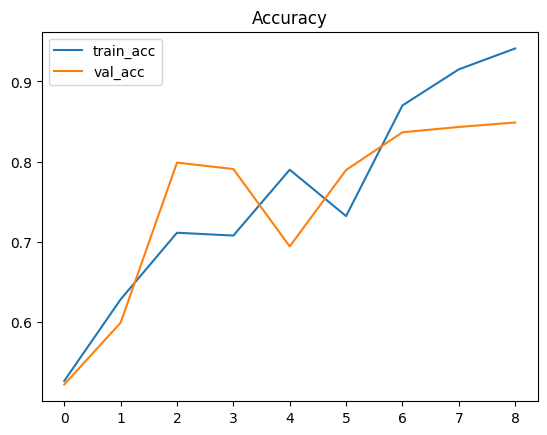

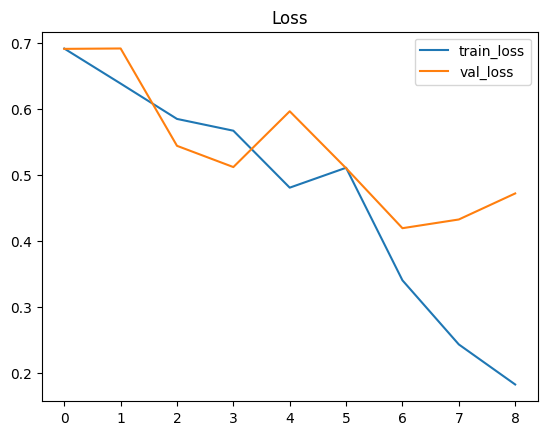

In [56]:
import matplotlib.pyplot as plt
plt.plot(History.history['accuracy'], label='train_acc')
plt.plot(History.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.plot(History.history['loss'], label='train_loss')
plt.plot(History.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.show()

In [57]:
model.save("lstm_sentiment.h5")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [58]:
from google.colab import files
files.download("lstm_sentiment.h5")
files.download("tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>